In [7]:
import seaborn as sns

penguins = sns.load_dataset("penguins")


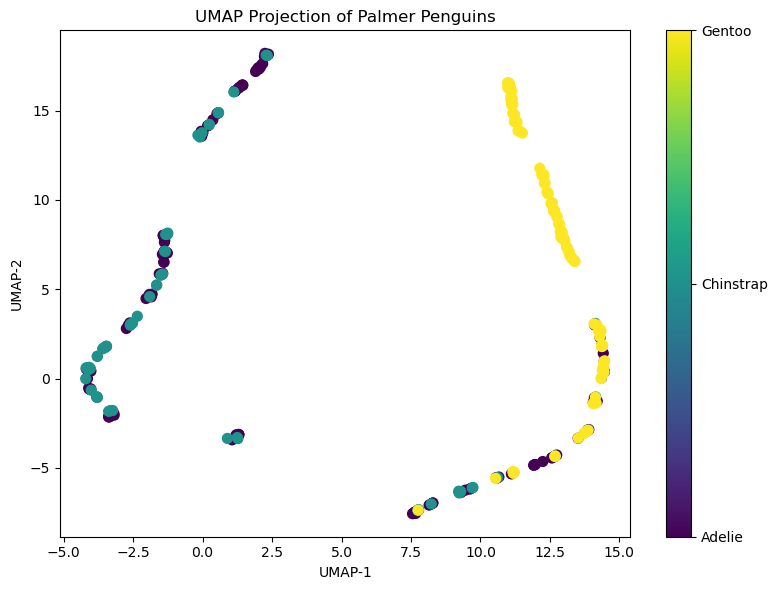

In [12]:
import seaborn as sns
from umap import UMAP
import matplotlib.pyplot as plt

# 1. Load and clean the Penguins dataset
penguins = sns.load_dataset("penguins").dropna()
X = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].values
y = penguins['species'].astype('category').cat.codes
species = penguins['species'].astype('category').cat.categories

# 2. Compute UMAP embedding
reducer = UMAP()
embedding = reducer.fit_transform(X)

# 3. Plot
plt.figure(figsize=(8, 6))
sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=y, s=50)
cb = plt.colorbar(sc, ticks=[0, 1, 2])
cb.set_ticklabels(species)
plt.title('UMAP Projection of Palmer Penguins')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.tight_layout()
plt.show()

/Users/swarchol/mambaforge/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


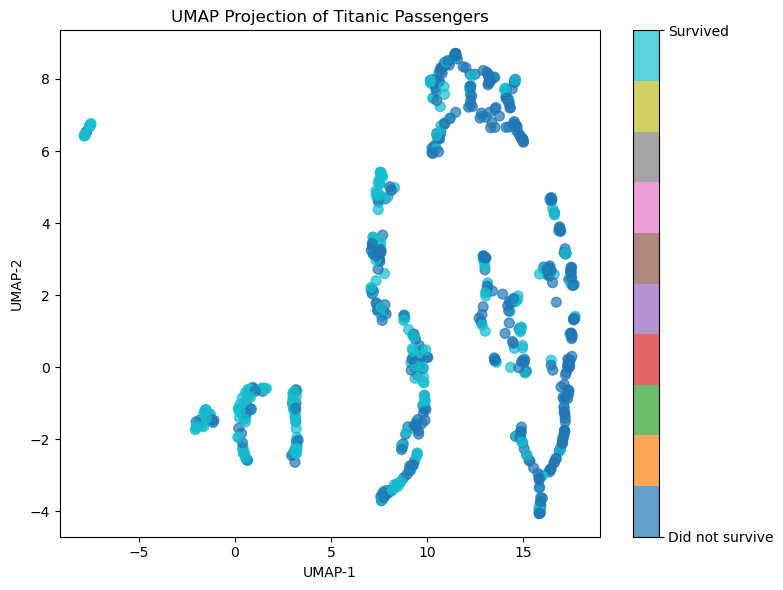

In [13]:
import seaborn as sns
from umap import UMAP
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load and preprocess Titanic
titanic = sns.load_dataset("titanic").dropna(subset=["age", "fare", "sex", "pclass", "survived"])
# Select numeric features and encode categoricals
X = titanic[["age", "fare", "pclass"]].copy()
X["sex"] = titanic["sex"].map({"male": 0, "female": 1})
y = titanic["survived"]  # 0 = did not survive, 1 = survived

# 2. Compute UMAP embedding
reducer = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(X)

# 3. Plot colored by survival
plt.figure(figsize=(8, 6))
sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap="tab10", s=50, alpha=0.7)
cb = plt.colorbar(sc, ticks=[0, 1])
cb.set_ticklabels(["Did not survive", "Survived"])
plt.title("UMAP Projection of Titanic Passengers")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()